<a href="https://colab.research.google.com/github/Akshatha7710/Face-Map/blob/main/FaceMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Face Images.zip to Face Images.zip
Found 15 valid images


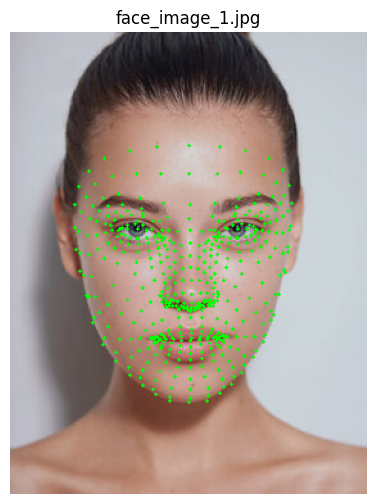

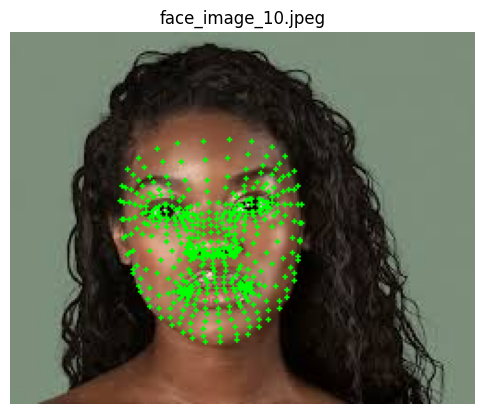

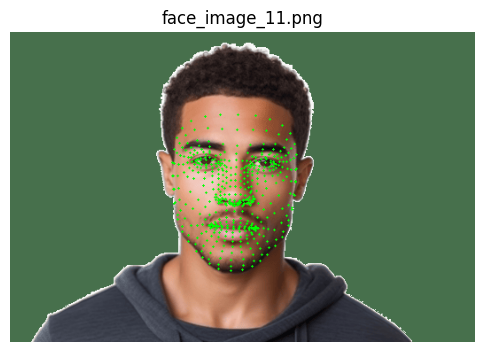

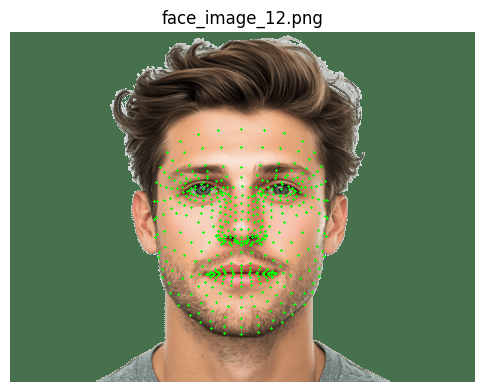

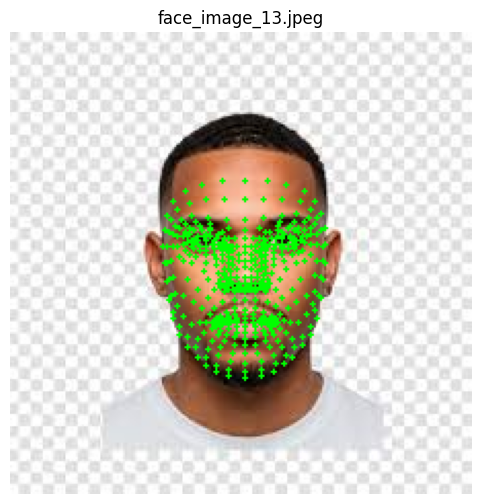

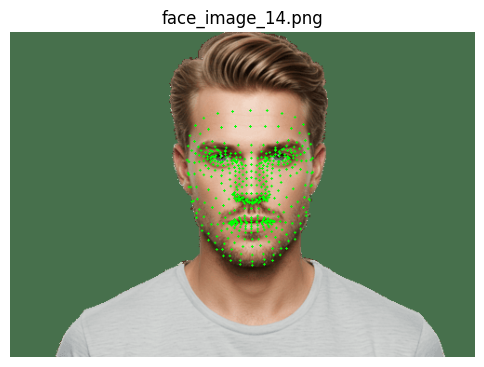

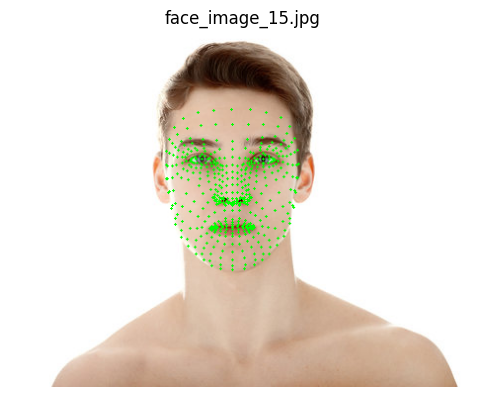

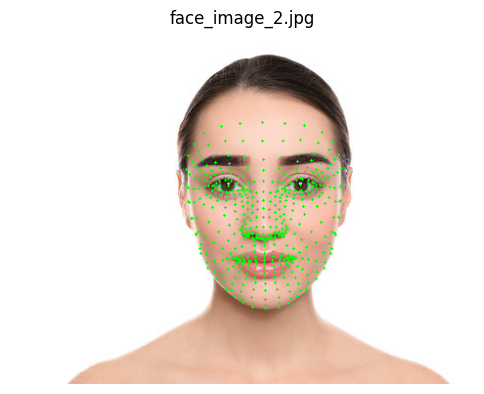

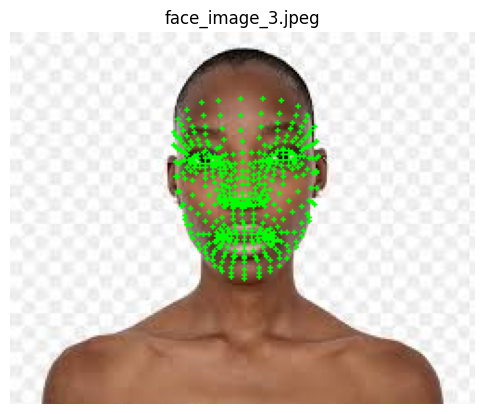

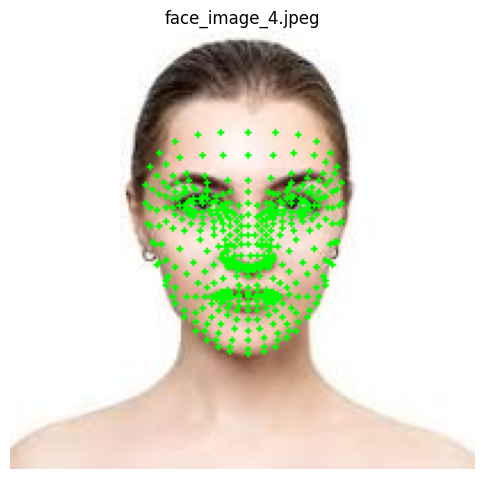

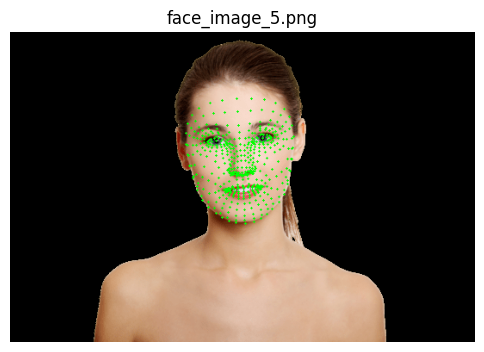

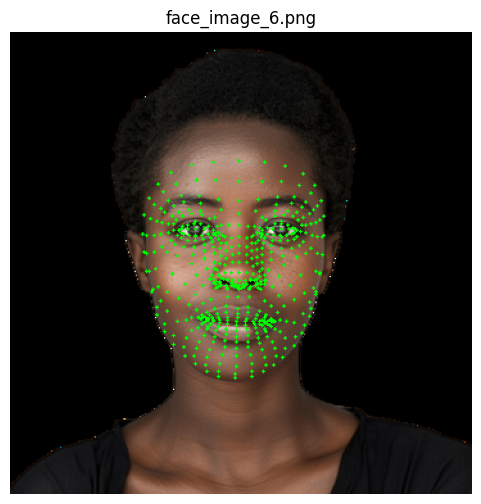

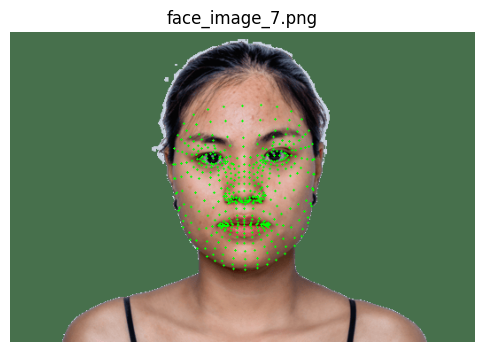

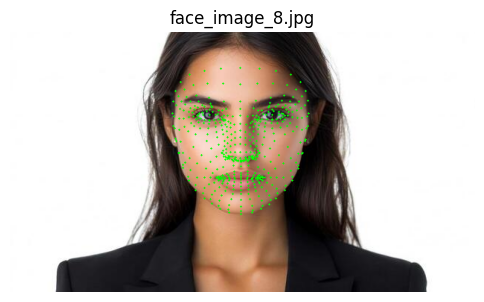

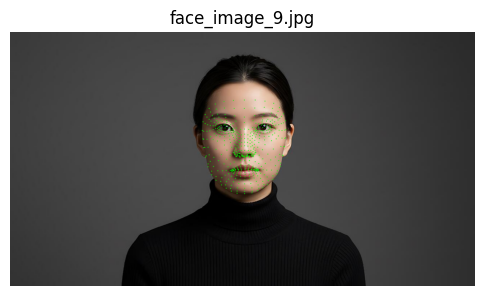

In [7]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files

# Upload and extract
uploaded = files.upload()
with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as zip_ref:
    zip_ref.extractall("/content/images")

# Find images — skip __MACOSX metadata files
image_paths = []
for root, dirs, files_list in os.walk("/content/images"):
    if "__MACOSX" in root:
        continue
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'):
            image_paths.append(os.path.join(root, f))

image_paths.sort()
print(f"Found {len(image_paths)} valid images")

# Download the MediaPipe face landmarker model
os.system("wget -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task")

# Set up MediaPipe Tasks API
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='face_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)

# Process all images
with FaceLandmarker.create_from_options(options) as landmarker:
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            print(f"Skipping (unreadable): {image_path}")
            continue

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        result = landmarker.detect(mp_image)

        if result.face_landmarks:
            h, w, _ = image.shape
            for face in result.face_landmarks:
                for landmark in face:
                    x, y = int(landmark.x * w), int(landmark.y * h)
                    cv2.circle(image, (x, y), 1, (0, 255, 0), -1)

            plt.figure(figsize=(6, 6))
            plt.title(os.path.basename(image_path))
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()
        else:
            print(f"No face detected in: {os.path.basename(image_path)}")